## PROCESO DE LIMPIEZA


In [2]:
# Configuración y librerías
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Estilo y tamaño de gráficos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
%matplotlib inline

# Ruta de la carpeta con los datos
CARPETA_DATOS = Path(r"../sources/data/Original")
archivos = list(CARPETA_DATOS.glob("*.csv"))
print("Archivos CSV encontrados:", [f.name for f in archivos])

Archivos CSV encontrados: ['Balanced_AHR.csv', 'Big_AHR.csv', 'datasetUnificadoReviewsHoteles.csv', 'dataset_hoteles_es_final_UTF8BOM.csv', 'df_limpio.csv', 'df_reviews_unificado_final.csv', 'resenas_hotel.csv']


## Problema de encoding

Es lo primero que debemos resolver porque si el encoding está roto, todas las limpiezas posteriores operan sobre basura

In [3]:
import chardet

def detectar_encoding(ruta_archivo):
    with open(ruta_archivo, "rb") as f:
        muestra = f.read(100_000)
    resultado = chardet.detect(muestra)
    print(f"Encoding detectado: {resultado['encoding']} "
          f"(confianza: {resultado['confidence']:.0%})")
    return resultado["encoding"]

encoding = detectar_encoding(CARPETA_DATOS / "df_reviews_unificado_final.csv")
df_reviews = pd.read_csv(CARPETA_DATOS / "df_reviews_unificado_final.csv", sep=",", encoding=encoding)

Encoding detectado: utf-8 (confianza: 84%)


In [5]:
import random
from datetime import datetime, timedelta

# Definir rango de fechas
fecha_inicio = datetime(2026, 1, 1)
fecha_fin    = datetime(2026, 3, 30)
num_rows = 100  # Puedes ajustar la cantidad de filas

# Reviews genéricas de ejemplo
ejemplos_reviews = [
    "El hotel fue excelente, muy cómodo y bien ubicado.",
    "No me gustó la atención en la recepción.",
    "La habitación estaba limpia y era espaciosa.",
    "El desayuno fue variado y delicioso.",
    "Tuvimos problemas con el aire acondicionado.",
    "La piscina estaba cerrada durante nuestra visita.",
    "Personal amable y servicial en todo momento.",
    "El precio es justo para la calidad ofrecida.",
    "Volvería sin dudarlo, una gran experiencia.",
    "La ubicación es inmejorable, cerca de todo.",
    "Fiestas ruidosas en la noche, mala experiencia.",
    "El wifi funcionaba perfectamente en todo el hotel.",
    "La cama era muy cómoda, dormí de maravilla.",
    "No había agua caliente en la ducha.",
    "El baño necesitaba mejor limpieza.",
    "El estacionamiento es amplio y seguro.",
    "El ascensor era muy lento.",
    "Nunca limpiaron la habitación durante mi estadía.",
    "Cerca del metro y restaurantes.",
    "El minibar estaba vacío."
]

data = []
for _ in range(num_rows):
    review = random.choice(ejemplos_reviews)
    # Generar fecha aleatoria entre inicio y fin
    rango_dias = (fecha_fin - fecha_inicio).days
    fecha = fecha_inicio + timedelta(days=random.randint(0, rango_dias))
    # Fecha en formato ISO YYYY-MM-DD
    data.append({"review": review, "fecha": fecha.date().isoformat()})

# Guardar el CSV
df_pruebas = pd.DataFrame(data)
df_pruebas.to_csv("reviews_pruebas_fechas.csv", index=False)
print("Archivo 'reviews_pruebas_fechas.csv' generado satisfactoriamente.")

Archivo 'reviews_pruebas_fechas.csv' generado satisfactoriamente.


In [3]:
def reparar_encoding_roto(texto):
    """
    Repara doble-encoding latin-1 → utf-8.
    'Ã±' → 'ñ', 'Ã©' → 'é', etc.
    """
    if not isinstance(texto, str):
        return texto
    try:
        return texto.encode("latin-1").decode("utf-8")
    except (UnicodeEncodeError, UnicodeDecodeError):
        return texto  # ya estaba bien, no tocar

# Detectar si tu dataset tiene este problema
muestra_rota = df_reviews["review"].str.contains(r"Ã|â€|Â·", regex=True).sum()
print(muestra_rota)
if muestra_rota > 0:
    print(f"Encoding roto detectado en {muestra_rota} filas — aplicando reparación")
    df_reviews["review"] = df_reviews["review"].apply(reparar_encoding_roto)

0


In [4]:
df_reviews

,review,sentimiento,idioma
0,El fin de semana mi pareja y yo hicimos una re...,negativo,es
1,"El hotel en general está bien, las habtiacione...",neutro,es
2,"El hotel es moderno, amplio y limpio, pero no ...",neutro,es
3,Calefacción averiada o no operativa. Se coment...,negativo,es
4,Este hotel ha bajado notoriamente su categoria...,negativo,es
...,...,...,...
9740,Pero la cama no era muy comoda. Me gusto el se...,neutro,es
9741,"Muy bien ubicado cerca al centro, igual el col...",neutro,es
9742,Las camas eran comodas. sin embargo el persona...,neutro,es
9743,Buen servicio dehabitaciones. Volvería.,positivo,es


In [5]:
# Eliminar Duplicados, quedándose con la primera ocurrencia
df_reviews = df_reviews.drop_duplicates(subset='review', keep='first').reset_index(drop=True)

In [6]:
from rapidfuzz import fuzz
import numpy as np

def encontrar_casi_duplicados(textos, umbral=90):
    """
    Retorna pares de índices con similitud >= umbral.
    Complejidad O(n²) — funciona bien hasta ~10k registros.
    """
    duplicados = []
    textos = list(textos)
    for i in range(len(textos)):
        for j in range(i + 1, len(textos)):
            score = fuzz.ratio(textos[i], textos[j])
            if score >= umbral:
                duplicados.append((i, j, score))
    return duplicados

pares = encontrar_casi_duplicados(df_reviews['review'], umbral=90)
print(f"Pares casi-duplicados encontrados: {len(pares)}")

# Ver ejemplos
for i, j, score in pares[:5]:
    print(f"\nSimilitud: {score}%")
    print(f"  A: {df_reviews['review'].iloc[i][:80]}")
    print(f"  B: {df_reviews['review'].iloc[j][:80]}")

Pares casi-duplicados encontrados: 2606

Similitud: 98.1858902575588%
  A: Esta opinión que habeis públicado no es de Cakis de Utrera es de Carlos de utrer
  B: Estuve alojado en el Hotel los Alamos el primer fin de semana de Agosto con mi m

Similitud: 91.22807017543859%
  A: La habitacion rstaba limpiia.
  B: La habitación estaba limpia.

Similitud: 94.73684210526316%
  A: La habitacion rstaba limpiia.
  B: La habitacion estaba limpia.

Similitud: 92.85714285714286%
  A: La habitacion rstaba limpiia.
  B: La habitacion estabalimpia.

Similitud: 92.85714285714286%
  A: La habitacion rstaba limpiia.
  B: La habitacion estaba limpia


In [7]:
import unicodedata
import re

def normalizar_para_comparacion(texto):
    # Minúsculas
    texto = texto.lower()
    # Quitar tildes solo para comparar (no modifica el dataset original)
    texto = unicodedata.normalize('NFD', texto)
    texto = ''.join(c for c in texto if unicodedata.category(c) != 'Mn')
    # Colapsar espacios
    texto = re.sub(r'\s+', ' ', texto).strip()
    # Quitar puntuación
    texto = re.sub(r'[^\w\s]', '', texto)
    return texto

df_reviews['review_norm'] = df_reviews['review'].apply(normalizar_para_comparacion)

# Duplicados exactos después de normalizar
df_sin_dup = df_reviews.drop_duplicates(subset='review_norm', keep='first')
df_sin_dup = df_sin_dup.drop(columns='review_norm')

In [8]:
def limpiar_duplicados(df, col_texto='review', col_etiqueta='sentimiento', umbral_fuzzy=90):
    reporte = {}
    reporte['total_inicial'] = len(df)

    # Paso 1: normalizar para comparación
    df['_norm'] = df[col_texto].apply(normalizar_para_comparacion)

    # Paso 2: detectar conflictos de etiqueta antes de eliminar
    conflictos = df[df.duplicated(subset='_norm', keep=False)]
    conflictos_multi = conflictos.groupby('_norm')[col_etiqueta].nunique()
    conflictos_reales = conflictos_multi[conflictos_multi > 1]
    reporte['conflictos_etiqueta'] = len(conflictos_reales)
    if len(conflictos_reales) > 0:
        print(f"Advertencia: {len(conflictos_reales)} textos tienen etiquetas inconsistentes.")

    # Paso 3: eliminar duplicados exactos (normalizados)
    df = df.drop_duplicates(subset='_norm', keep='first').reset_index(drop=True)
    reporte['tras_exactos'] = len(df)

    # Paso 4: fuzzy matching (solo si el dataset no es muy grande)
    if len(df) <= 15000:
        pares = encontrar_casi_duplicados(df[col_texto], umbral=umbral_fuzzy)
        indices_a_eliminar = set(j for _, j, _ in pares)
        df = df.drop(index=list(indices_a_eliminar)).reset_index(drop=True)
        reporte['casi_duplicados_eliminados'] = len(indices_a_eliminar)

    df = df.drop(columns='_norm')
    reporte['total_final'] = len(df)
    reporte['eliminados'] = reporte['total_inicial'] - reporte['total_final']

    return df, reporte

df_limpio, reporte = limpiar_duplicados(df_reviews)
print(reporte)

{'total_inicial': 9745, 'conflictos_etiqueta': 0, 'tras_exactos': 9558, 'casi_duplicados_eliminados': 1242, 'total_final': 8316, 'eliminados': 1429}


Detectamos Idiomas

In [9]:

from lingua import Language, LanguageDetectorBuilder

# Definir los idiomas que esperas encontrar
# Limitar el detector mejora la precisión en textos cortos
idiomas = [
    Language.SPANISH,
    Language.ENGLISH,
    Language.FRENCH,
    Language.PORTUGUESE,
    Language.GERMAN,
    Language.ITALIAN,
]

detector = LanguageDetectorBuilder.from_languages(*idiomas).build()

def detectar_idioma(texto):
    if not texto or len(texto.strip()) < 5:
        return "desconocido"
    resultado = detector.detect_language_of(texto)
    return resultado.iso_code_639_1.name.lower() if resultado else "desconocido"

df_limpio["idioma"] = df_limpio["review"].apply(detectar_idioma)
print(df_limpio["idioma"].value_counts())

idioma
es    8262
en      21
pt      12
fr      10
it       8
de       3
Name: count, dtype: int64


Revisamos la confiaza de la deteccion

In [10]:
def detectar_con_confianza(texto):
    if not texto or len(texto.strip()) < 5:
        return "desconocido", 0.0
    
    resultados = detector.compute_language_confidence_values(texto)
    if not resultados:
        return "desconocido", 0.0
    
    mejor = resultados[0]
    idioma = mejor.language.iso_code_639_1.name.lower()
    confianza = mejor.value  # entre 0 y 1
    return idioma, round(confianza, 3)

df_limpio[["idioma", "confianza"]] = df_limpio["review"].apply(
    lambda x: pd.Series(detectar_con_confianza(x))
)

# Ver distribución de confianza
print(df_limpio.groupby("idioma")["confianza"].describe())

         count      mean       std    min      25%    50%    75%  max
idioma                                                               
de         3.0  1.000000  0.000000  1.000  1.00000  1.000  1.000  1.0
en        21.0  0.967143  0.150570  0.310  1.00000  1.000  1.000  1.0
es      8262.0  0.977700  0.062920  0.330  0.99400  1.000  1.000  1.0
fr        10.0  1.000000  0.000000  1.000  1.00000  1.000  1.000  1.0
it         8.0  0.940875  0.167231  0.527  1.00000  1.000  1.000  1.0
pt        12.0  0.572833  0.144762  0.442  0.50625  0.527  0.586  1.0


Las reviews de hoteles tienen tres situaciones que engañan a cualquier detector:

In [11]:
# Caso 1: Spanglish — mezcla real en una misma review
# "El check-in fue muy smooth, el staff super friendly"
# → lingua detecta ES, pero tiene fragmentos EN

# Caso 2: Texto demasiado corto para detectar con certeza
# "Ok." / "Bien" / "Good" → alta ambigüedad

# Caso 3: Nombres propios en otro idioma
# "Pregunté por el 'breakfast' y el 'pool'" → puede confundir

# Estrategia: zona de cuarentena para baja confianza
UMBRAL_CONFIANZA = 0.75

df_limpio["categoria_idioma"] = "otros"
df_limpio.loc[(df_limpio["idioma"] == "es") & (df_limpio["confianza"] >= UMBRAL_CONFIANZA), "categoria_idioma"] = "español_seguro"
df_limpio.loc[(df_limpio["idioma"] == "es") & (df_limpio["confianza"] < UMBRAL_CONFIANZA), "categoria_idioma"] = "español_dudoso"
df_limpio.loc[(df_limpio["idioma"] != "es") & (df_limpio["confianza"] >= UMBRAL_CONFIANZA), "categoria_idioma"] = "otro_idioma"
df_limpio.loc[df_limpio["idioma"] == "desconocido", "categoria_idioma"] = "muy_corto"

print(df_limpio["categoria_idioma"].value_counts())

categoria_idioma
español_seguro    8098
español_dudoso     164
otro_idioma         41
otros               13
Name: count, dtype: int64


In [12]:
# Separar en grupos para tomar decisiones distintas
español_limpio   = df_limpio[df_limpio["categoria_idioma"] == "español_seguro"]
español_dudoso   = df_limpio[df_limpio["categoria_idioma"] == "español_dudoso"]
otros_idiomas    = df_limpio[df_limpio["categoria_idioma"] == "otro_idioma"]
muy_cortos       = df_limpio[df_limpio["categoria_idioma"] == "muy_corto"]

print(f"Español seguro  : {len(español_limpio):>5}")
print(f"Español dudoso  : {len(español_dudoso):>5}  ← revisar manualmente")
print(f"Otro idioma     : {len(otros_idiomas):>5}  ← decidir qué hacer")
print(f"Muy cortos      : {len(muy_cortos):>5}  ← probablemente eliminar")

Español seguro  :  8098
Español dudoso  :   164  ← revisar manualmente
Otro idioma     :    41  ← decidir qué hacer
Muy cortos      :     0  ← probablemente eliminar


# Traduccion Automatica, en realidad no vale la pena traducir La traducción automática tiene un costo porque introduce ruido semántico, y para análisis de sentimiento puede distorsionar frases importantes. Solo vale la pena si los reviews en otros idiomas son una porción significativa del dataset (>10%) en este caso no es ni el 1%

In [13]:
#from deep_translator import GoogleTranslator

#def traducir_a_español(texto, idioma_origen):
#    try:
#        if idioma_origen == "es":
#            return texto
#        traductor = GoogleTranslator(source=idioma_origen, target="es")
#        return traductor.translate(texto)
#    except Exception:
#        return None  # marcar para revisión si falla

# Solo traducir los que tenemos certeza del idioma origen
#mask = (df["categoria_idioma"] == "otro_idioma") & (df["idioma"] != "desconocido")
#df.loc[mask, "review"] = df.loc[mask].apply(
#    lambda row: traducir_a_español(row["review"], row["idioma"]), axis=1
#)

Borramos lo que no es español seguro

In [14]:
def detectar_idiomas(df, col_texto="review", umbral_confianza=0.75):
    
    detector = LanguageDetectorBuilder.from_languages(*idiomas).build()
    
    df[["idioma", "confianza"]] = df[col_texto].apply(
        lambda x: pd.Series(detectar_con_confianza(x))
    )
    
    df["categoria_idioma"] = "otros"
    df.loc[(df["idioma"] == "es") & (df["confianza"] >= umbral_confianza), "categoria_idioma"] = "español_seguro"
    df.loc[(df["idioma"] == "es") & (df["confianza"] < umbral_confianza),  "categoria_idioma"] = "español_dudoso"
    df.loc[(df["idioma"] != "es") & (df["confianza"] >= umbral_confianza), "categoria_idioma"] = "otro_idioma"
    df.loc[df["idioma"] == "desconocido", "categoria_idioma"] = "muy_corto"
    
    # Reporte
    total = len(df)
    print("=== Reporte de detección de idioma ===")
    for cat, grupo in df.groupby("categoria_idioma"):
        pct = len(grupo) / total * 100
        idiomas_en_grupo = grupo["idioma"].value_counts().head(3).to_dict()
        print(f"  {cat:<20}: {len(grupo):>5} ({pct:.1f}%) — {idiomas_en_grupo}")
    
    # Muestra de los dudosos para revisión manual
    print("\n--- Muestra español dudoso (revisar) ---")
    print(df[df["categoria_idioma"] == "español_dudoso"][col_texto].head(5).to_string())
    
    return df

df_limpio = detectar_idiomas(df_limpio)

=== Reporte de detección de idioma ===
  español_dudoso      :   164 (2.0%) — {'es': 164}
  español_seguro      :  8098 (97.4%) — {'es': 8098}
  otro_idioma         :    41 (0.5%) — {'en': 20, 'fr': 10, 'it': 7}
  otros               :    13 (0.2%) — {'pt': 11, 'en': 1, 'it': 1}

--- Muestra español dudoso (revisar) ---
5868                     El check in fuerapido. Volvería.
5874                                El cuarto era amplio.
5890                 El parqueadero fue util. Sin quejas.
5894            Honestamente Elservicio fue algodemorado.
5901    No pude dormir bien por el ruido y lacomida se...


In [15]:
df_limpio = df_limpio[df_limpio["categoria_idioma"] == "español_seguro"].copy()

## . Diagnóstico previo — antes de limpiar, auditamos

In [16]:
import pandas as pd
import re


# Ver ejemplos de problemas reales en tu dataset
def diagnosticar_texto(df, col="review", muestra=5):
    problemas = {
        "tiene_html":      df[col].str.contains(r"<[^>]+>", regex=True),
        "tiene_entities":  df[col].str.contains(r"&\w+;|&#\d+;", regex=True),
        "tiene_urls":      df[col].str.contains(r"https?://|www\.", regex=True),
        "tiene_ctrl":      df[col].str.contains(r"[\x00-\x08\x0b\x0c\x0e-\x1f]", regex=True),
        "espacios_multi":  df[col].str.contains(r"  +", regex=True),
        "encoding_roto":   df[col].str.contains(r"Ã|â€|Â·|Ã±", regex=True),
    }
    for nombre, mask in problemas.items():
        count = mask.sum()
        if count > 0:
            print(f"  {nombre:<20}: {count:>5} filas ({count/len(df)*100:.1f}%)")
            print(f"    Ejemplo: {df.loc[mask, col].iloc[0][:80]}")

diagnosticar_texto(df_limpio)

  tiene_urls          :     1 filas (0.0%)
    Ejemplo: Ubicación muy céntrica con el inconveniente de que justo pared con pared hay una
  espacios_multi      :  1789 filas (22.1%)
    Ejemplo: El fin de semana mi pareja y yo hicimos una reserva en este hotel, con el fin de


## Limpieza de HTML y Entidades

In [17]:
from bs4 import BeautifulSoup
import html

def limpiar_html(texto):
    if not isinstance(texto, str):
        return texto
    
    # Paso 1: decodificar entidades HTML (&amp; → &, &ntilde; → ñ, &#243; → ó)
    texto = html.unescape(texto)
    
    # Paso 2: eliminar tags HTML con BeautifulSoup
    # Más robusto que regex para HTML malformado
    if re.search(r"<[^>]+>", texto):
        texto = BeautifulSoup(texto, "html.parser").get_text(separator=" ")
    
    # Paso 3: entidades que quedaron sin parsear (&nbsp; → espacio)
    texto = re.sub(r"&nbsp;", " ", texto)
    texto = re.sub(r"&[a-zA-Z]+;", " ", texto)   # entidades nombradas restantes
    texto = re.sub(r"&#\d+;", " ", texto)          # entidades numéricas restantes
    
    return texto

#df_limpio["review"] = df_limpio["review"].apply(limpiar_html)

## Limpieza de caracteres especiales y de control
- Aquí la decisión más importante: qué conservas y qué eliminas. Para reviews en español orientadas a sentimiento:

In [18]:
import unicodedata

def limpiar_caracteres(texto, modo="bert"):
    """
    modo='bert'    → conserva tildes, ñ, puntuación básica
    modo='clasico' → elimina tildes, reduce puntuación
    """
    if not isinstance(texto, str):
        return texto
    
    # Caracteres de control (excepto \n y \t que pueden ser útiles)
    texto = re.sub(r"[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]", "", texto)
    
    # Caracteres Unicode problemáticos frecuentes en reviews
    reemplazos = {
        "\u2019": "'",   # comilla curva derecha → apóstrofe
        "\u2018": "'",   # comilla curva izquierda
        "\u201c": '"',   # comilla doble izquierda
        "\u201d": '"',   # comilla doble derecha
        "\u2013": "-",   # guión largo (en dash)
        "\u2014": "-",   # guión largo (em dash)
        "\u2026": "...", # puntos suspensivos unicode
        "\u00b7": "·",   # punto medio (común en catalán/español)
        "\xa0":   " ",   # non-breaking space
    }
    for orig, reemplazo in reemplazos.items():
        texto = texto.replace(orig, reemplazo)
    
    if modo == "clasico":
        # Normalizar NFC → quita acentos si se quiere
        texto = unicodedata.normalize("NFD", texto)
        texto = "".join(c for c in texto
                        if unicodedata.category(c) != "Mn")  # Mn = diacrítico
        # Conservar solo alfanuméricos, espacios y puntuación básica
        texto = re.sub(r"[^a-zA-Z0-9\sáéíóúüñ.,;:!?¡¿\-']", " ", texto)
    
    elif modo == "bert":
        # Conservar tildes y ñ — BERT en español las necesita
        # Solo eliminar símbolos sin valor semántico
        texto = re.sub(r"[^\w\sáéíóúüñÁÉÍÓÚÜÑ.,;:!?¡¿\-'\"()\n]", " ", texto)
    
    return texto

#df_limpio["review"] = df_limpio["review"].apply(lambda x: limpiar_caracteres(x, modo="bert"))

## Normalización de espacios y saltos de línea

In [19]:
def normalizar_espacios(texto):
    if not isinstance(texto, str):
        return texto
    
    # Convertir saltos de línea múltiples a uno solo
    texto = re.sub(r"\n{2,}", "\n", texto)
    
    # Colapsar espacios múltiples en uno
    texto = re.sub(r"[ \t]+", " ", texto)
    
    # Quitar espacios antes de puntuación
    texto = re.sub(r"\s+([.,;:!?])", r"\1", texto)
    
    # Quitar espacios al inicio y final
    texto = texto.strip()
    
    return texto

#df_limpio["review"] = df_limpio["review"].apply(normalizar_espacios)

In [20]:
def limpiar_texto_completo(df, col="review", modo="bert"):
    
    df = df.copy()
    stats = {"filas_iniciales": len(df)}
    
    # Guardar muestra original para comparar
    muestra_idx = df.sample(min(3, len(df))).index
    
    print("Aplicando limpieza...")
    
    df[col] = df[col].apply(reparar_encoding_roto)
    print("  [1/4] Encoding reparado")
    
    df[col] = df[col].apply(limpiar_html)
    print("  [2/4] HTML y entidades eliminados")
    
    df[col] = df[col].apply(lambda x: limpiar_caracteres(x, modo=modo))
    print("  [3/4] Caracteres especiales limpiados")
    
    df[col] = df[col].apply(normalizar_espacios)
    print("  [4/4] Espacios normalizados")
    
    # Eliminar filas que quedaron vacías tras la limpieza
    vacias_antes = df[col].isna().sum()
    df[col] = df[col].replace("", None)
    df = df.dropna(subset=[col]).reset_index(drop=True)
    vacias_despues = stats["filas_iniciales"] - len(df)
    
    stats["filas_finales"]  = len(df)
    stats["filas_perdidas"] = vacias_despues
    
    print(f"\n=== Reporte ===")
    print(f"  Filas iniciales : {stats['filas_iniciales']}")
    print(f"  Filas finales   : {stats['filas_finales']}")
    print(f"  Filas perdidas  : {stats['filas_perdidas']}")
    
    # Mostrar comparación antes/después
    print("\n--- Ejemplos antes → después ---")
    for idx in muestra_idx:
        if idx < len(df):
            print(f"  ANTES : {df[col].iloc[idx][:100]}")
    
    return df, stats

df_limpio, stats = limpiar_texto_completo(df_limpio, modo="bert")


Aplicando limpieza...
  [1/4] Encoding reparado
  [2/4] HTML y entidades eliminados
  [3/4] Caracteres especiales limpiados
  [4/4] Espacios normalizados

=== Reporte ===
  Filas iniciales : 8098
  Filas finales   : 8098
  Filas perdidas  : 0

--- Ejemplos antes → después ---
  ANTES : Precio justo por lo que ofrece, igual el ascensor tardaba mucho.
  ANTES : Estuvimos solo una noche mi marido y yo para pasar el finde, y cuando llegamos a recepción nos cobra
  ANTES : La verdad Falta mantenimiento en algunas areas.


## Por qué los emojis importan en reviews de hotele? En texto de redes sociales y reviews, un emoji puede ser la señal de sentimiento más fuerte de toda la oración. "La habitación limpia 🤮" vs "La habitación limpia" son dos sentimientos opuestos. Eliminarlos es perder información real.

cuántos emojis tenemos y cuáles

In [21]:
import emoji
import pandas as pd
from collections import Counter
import re

def extraer_emojis(texto):
    if not isinstance(texto, str):
        return []
    return [c for c in texto if c in emoji.EMOJI_DATA]

# Auditoría del dataset
todos_emojis = []
df_limpio["emojis_encontrados"] = df_limpio["review"].apply(extraer_emojis)
df_limpio["tiene_emoji"] = df_limpio["emojis_encontrados"].apply(len) > 0
df_limpio["num_emojis"] = df_limpio["emojis_encontrados"].apply(len)

todos_emojis = [e for lista in df_limpio["emojis_encontrados"] for e in lista]

print(f"Reviews con emojis : {df_limpio['tiene_emoji'].sum()} ({df_limpio['tiene_emoji'].mean()*100:.1f}%)")
print(f"Total emojis       : {len(todos_emojis)}")
print(f"\nTop 15 emojis más frecuentes:")
for em, count in Counter(todos_emojis).most_common(15):
    desc = emoji.EMOJI_DATA[em].get("es", emoji.EMOJI_DATA[em].get("en", ""))
    print(f"  {em}  {count:>4}x  —  {desc}")

Reviews con emojis : 0 (0.0%)
Total emojis       : 0

Top 15 emojis más frecuentes:


In [22]:
print("\nEmojis promedio por clase:")
print(df_limpio.groupby("sentimiento")["num_emojis"].mean().round(2))

# Los emojis más frecuentes por clase
for clase in df_limpio["sentimiento"].unique():
    subset = df_limpio[df_limpio["sentimiento"] == clase]["emojis_encontrados"]
    emojis_clase = [e for lista in subset for e in lista]
    top = Counter(emojis_clase).most_common(5)
    print(f"\n  {clase}: {top}")


Emojis promedio por clase:
sentimiento
negativo    0.0
neutro      0.0
positivo    0.0
Name: num_emojis, dtype: float64

  negativo: []

  neutro: []

  positivo: []


In [23]:
def limpiar_variantes_emoji(texto):
    if not isinstance(texto, str):
        return texto
    
    # Emoticones de texto: :) :( :D xD =) etc.
    emoticones = {
        r":\)": " cara_feliz ",
        r":\(": " cara_triste ",
        r":D":  " cara_muy_feliz ",
        r"xD":  " cara_riendo ",
        r"=\)": " cara_feliz ",
        r":\|": " cara_neutral ",
        r">:\(": " cara_enojada ",
        r";\)": " guiño ",
        r":/":  " cara_dudosa ",
    }
    for patron, reemplazo in emoticones.items():
        texto = re.sub(patron, reemplazo, texto, flags=re.IGNORECASE)
    
    # Repetición exagerada de emojis: 😍😍😍😍 → 😍 (intensidad ya captada por descripción)
    # Detectar secuencias del mismo emoji repetido más de 3 veces
    def colapsar_emojis_repetidos(t):
        resultado = []
        i = 0
        chars = list(t)
        while i < len(chars):
            c = chars[i]
            if c in emoji.EMOJI_DATA:
                count = 1
                while i + count < len(chars) and chars[i + count] == c:
                    count += 1
                if count >= 3:
                    resultado.append(c)  # colapsar a uno solo
                    resultado.append(" mucho ")
                else:
                    resultado.extend([c] * count)
                i += count
            else:
                resultado.append(c)
                i += 1
        return "".join(resultado)
    
    texto = colapsar_emojis_repetidos(texto)
    
    return texto

In [24]:
def procesar_emojis_para_bert(texto, idioma="es"):
    """
    Pipeline recomendado para BERT/LLMs en español:
    1. Limpiar variantes (emoticones, repeticiones)
    2. Convertir emojis a descripción en español
    3. Limpiar los delimitadores que deja demojize
    4. Normalizar espacios
    """
    if not isinstance(texto, str):
        return texto
    
    # Paso 1: variantes y emoticones
    texto = limpiar_variantes_emoji(texto)
    
    # Paso 2: emoji → descripción
    texto = emoji.demojize(texto, language=idioma)
    
    # Paso 3: limpiar delimitadores :descripcion_larga:
    # Opción A — conservar como tokens separados con espacios
    texto = re.sub(r":([a-záéíóúüñ_]+):", r" \1 ", texto)
    
    # Opción B — conservar con guiones bajos (más compacto)
    # texto = re.sub(r":([a-záéíóúüñ_]+):", r" EMJ_\1 ", texto)
    
    # Paso 4: normalizar espacios
    texto = re.sub(r"[ \t]+", " ", texto).strip()
    
    return texto

def procesar_emojis_para_clasicos(texto):
    """
    Para TF-IDF / FastText: eliminar emojis directamente.
    El vocabulario de bag-of-words no se beneficia de las descripciones.
    """
    if not isinstance(texto, str):
        return texto
    texto = limpiar_variantes_emoji(texto)
    texto = emoji.replace_emoji(texto, replace=" ")
    texto = re.sub(r"[ \t]+", " ", texto).strip()
    return texto

# Aplicar según el pipeline que estés construyendo
df_limpio["review"]    = df_limpio["review"].apply(procesar_emojis_para_bert)


## Limpieza de URLS, menciones y nopmbres propios
- En reviews de hoteles estos elementos aparecen con más frecuencia de lo esperado y no todos son ruido puro. Un número en "habitación 304 perfecta" no aporta nada, pero en "esperé 3 horas en recepción" o "cobran 50 mil pesos extra sin avisar" es parte central del sentimiento.

In [25]:
import pandas as pd
import re


patrones_diagnostico = {
    "urls":          r"https?://\S+|www\.\S+",
    "emails":        r"[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}",
    "menciones":     r"@\w+",
    "hashtags":      r"#\w+",
    "telefonos":     r"\+?\d[\d\s\-().]{7,}\d",
    "nums_solos":    r"\b\d+\b",
    "nums_precio":   r"\d+\s*€|\d+\s*\$|\d+\s*USD|\d+\s*EUR",
    "nums_hora":     r"\b\d{1,2}:\d{2}\b",
    "nums_fecha":    r"\b\d{1,2}/\d{1,2}/\d{2,4}\b",
    "habitacion":    r"\bhabitaci[oó]n\s*\d+|\broom\s*\d+|\b\d{3,4}\b",
}

print("=== Diagnóstico de ruido estructural ===\n")
for nombre, patron in patrones_diagnostico.items():
    mask = df_limpio["review"].str.contains(patron, regex=True, na=False)
    count = mask.sum()
    if count > 0:
        ejemplo = df_limpio.loc[mask, "review"].iloc[0][:500]
        print(f"  {nombre:<16}: {count:>4} filas — Ej: {ejemplo}")

=== Diagnóstico de ruido estructural ===

  telefonos       :   11 filas — Ej: Ayre Seville Poco simpáticos y publicidad inexacta 797571471 Hotel desaconsejable, pedí en la propia reserva de Booking que las ventanas se pudiera abrir. No contestaron y en cuanto estuve allí una recepcionista de forma poco educada me dijo que no que las ventanas no se pueden abrir que si no la gente se tiraria. Ante tal argumento Anule la habitación y me mintieron diciéndome que no cobrarían nada y si lo hicieron a pesar de que la reclamación la hice a través de Booking. No tengo constancia d
  nums_solos      : 2578 filas — Ej: El fin de semana mi pareja y yo hicimos una reserva en este hotel, con el fin de descansar y desconectar, fue sólo una noche y menos mal. Nos llevaron a un ala bastante apartada del hotel porque nos dijeron que era mejor para descansar ya que la parte de fuera era muy "jaleosa". Nos pareció bien porque era justo lo que buscábamos, y cuál fue nuestra sorpresa? Desde las 6 de la mañ

URLs
En reviews de hoteles las URLs casi nunca aportan sentimiento. Pero antes de eliminar, vale saber qué tipo son:

In [26]:
def clasificar_urls(texto):
    if not isinstance(texto, str):
        return []
    patron = r"https?://\S+|www\.\S+"
    return re.findall(patron, texto)

todas_urls = [u for lista in df_limpio["review"].apply(clasificar_urls) for u in lista]

# Ver qué dominios aparecen
dominios = []
for url in todas_urls:
    match = re.search(r"(?:https?://)?(?:www\.)?([^/\s]+)", url)
    if match:
        dominios.append(match.group(1))

from collections import Counter
print("Dominios más frecuentes en URLs:")
for dom, count in Counter(dominios).most_common(10):
    print(f"  {dom:<35}: {count}")

Dominios más frecuentes en URLs:


In [27]:
def limpiar_urls(texto, reemplazo=""):
    """
    reemplazo="" → elimina la URL completamente
    reemplazo="[URL]" → deja un token placeholder
    """
    if not isinstance(texto, str):
        return texto
    patron = r"https?://\S+|www\.\S+"
    return re.sub(patron, reemplazo, texto).strip()

# Para BERT/LLMs: eliminar directamente, no aportan
#df["texto"] = df["texto"].apply(limpiar_urls)

Telefonos Además de ser ruido para el modelo, son datos personales

In [28]:
def anonimizar_datos_personales(texto):
    if not isinstance(texto, str):
        return texto
    
    # Emails
    texto = re.sub(
        r"[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}",
        "[EMAIL]", texto
    )
    
    # Teléfonos (formatos latinoamericanos y europeos)
    texto = re.sub(
        r"\+?\d[\d\s\-().]{7,}\d",
        "[TELEFONO]", texto
    )
    
    # Números de tarjeta (por si acaso)
    texto = re.sub(
        r"\b\d{4}[\s\-]?\d{4}[\s\-]?\d{4}[\s\-]?\d{4}\b",
        "[TARJETA]", texto
    )
    
    return texto

#df["texto"] = df["texto"].apply(anonimizar_datos_personales)

# Menciones y hashtags
En reviews de TripAdvisor o Booking raramente aparecen, pero si el dataset viene de redes sociales debemos eliminarlos

In [29]:
def limpiar_menciones_hashtags(texto, modo="bert"):
    if not isinstance(texto, str):
        return texto
    
    if modo == "bert":
        # Conservar el texto del hashtag, quitar el símbolo
        # #MuyBuenServicio → MuyBuenServicio (información útil)
        texto = re.sub(r"#(\w+)", r"\1", texto)
        # Menciones: eliminar completamente (no aportan)
        texto = re.sub(r"@\w+", "", texto)
    
    elif modo == "clasico":
        # Eliminar ambos completamente
        texto = re.sub(r"[#@]\w+", "", texto)
    
    return texto.strip()

# Números 
Este es el elemento donde más diferencia hay entre eliminar a ciegas y hacerlo con criterio. Los números en reviews de hoteles caen en categorías muy distintas


In [30]:
# Categorías de números en reviews de hoteles
ejemplos = {
    "con_sentimiento":  [
        "esperé 3 horas para hacer el check-in",      # tiempo de espera → negativo
        "cobran 80€ de parking sin avisarlo",          # precio inesperado → negativo
        "dieron habitación en piso 12 con vista al mar", # ubicación → positivo
        "calificación 2 de 10, deplorable",            # puntuación explícita
    ],
    "sin_sentimiento": [
        "habitación 304",          # número de habitación
        "reserva #4521873",        # código de reserva
        "tel: 34 91 234 5678",     # teléfono (ya limpiado antes)
        "calle mayor 15, Madrid",  # dirección
    ],
    "ambiguos": [
        "100% recomendado",        # porcentaje con valor positivo
        "5 estrellas",             # valoración
        "solo 2 enchufes",         # escasez → negativo implícito
    ],
}

In [31]:
def procesar_numeros(texto, modo="bert"):
    if not isinstance(texto, str):
        return texto
    
    if modo == "bert":
        # Para BERT: conservar números con contexto semántico,
        # eliminar solo los que claramente son ruido
        
        # Números de habitación: quitar solo el número, conservar "habitación"
        texto = re.sub(
            r"\b(habitaci[oó]n|room|piso|planta|suite)\s*\d+",
            r"\1", texto, flags=re.IGNORECASE
        )
        
        # Códigos de reserva (secuencias largas de dígitos sin contexto)
        texto = re.sub(r"\b\d{6,}\b", "", texto)
        
        # Fechas (ya no aportan sentimiento en reviews)
        texto = re.sub(r"\b\d{1,2}/\d{1,2}/\d{2,4}\b", "", texto)
        texto = re.sub(r"\b\d{4}-\d{2}-\d{2}\b", "", texto)
        
        # Conservar: precios, horas, duraciones, puntuaciones
        # "3 horas", "80€", "5 estrellas", "2 de 10" → dejar intactos
    
    elif modo == "clasico":
        # Para TF-IDF: los números raramente están en el vocabulario útil
        # Reemplazar todos por token genérico
        texto = re.sub(r"\b\d+([.,]\d+)?\b", "[NUM]", texto)
        # O eliminar directamente
        # texto = re.sub(r"\b\d+([.,]\d+)?\b", " ", texto)
    
    return texto

#df["texto"] = df["texto"].apply(lambda x: procesar_numeros(x, modo="bert"))

# Nombres propios — decisión de privacidad y sesgo

In [32]:
# En reviews de hoteles aparecen nombres de staff con frecuencia:
# "Gracias a María en recepción, excelente atención"
# "El señor González del restaurante fue grosero"
#
# Para el modelo de sentimiento no aportan, pero sí pueden
# introducir sesgo si algunos nombres aparecen solo en reviews
# positivas o negativas por casualidad estadística.

# Opción simple: usar spaCy para detectar y reemplazar
# pip install spacy
# python -m spacy download es_core_news_sm

import spacy
nlp = spacy.load("es_core_news_sm")

def anonimizar_nombres(texto):
    if not isinstance(texto, str):
        return texto
    doc = nlp(texto)
    resultado = texto
    # Reemplazar entidades tipo persona de derecha a izquierda
    # para no desplazar índices
    for ent in reversed(doc.ents):
        if ent.label_ == "PER":
            resultado = resultado[:ent.start_char] + "[PERSONA]" + resultado[ent.end_char:]
    return resultado

# Aplicar solo si privacidad es requisito del proyecto
# df["texto"] = df["texto"].apply(anonimizar_nombres)

c:\Estudio\Maestria\.venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.3.0)/charset_normalizer (3.4.3) doesn't match a supported version!
  warnings.warn(


In [33]:
def limpiar_ruido_estructural(df, col="review", modo="bert",
                               anonimizar=True, nombres=True):
    df = df.copy()
    pasos = []

    df[col] = df[col].apply(limpiar_urls)
    pasos.append("URLs eliminadas")

    df[col] = df[col].apply(anonimizar_datos_personales)
    pasos.append("Emails y teléfonos anonimizados")

    df[col] = df[col].apply(
        lambda x: limpiar_menciones_hashtags(x, modo=modo)
    )
    pasos.append("Menciones y hashtags limpiados")

    df[col] = df[col].apply(
        lambda x: procesar_numeros(x, modo=modo)
    )
    pasos.append("Números procesados")

    if nombres:
        df[col] = df[col].apply(anonimizar_nombres)
        pasos.append("Nombres propios anonimizados")

    # Normalizar espacios que quedaron tras eliminaciones
    df[col] = df[col].apply(
        lambda x: re.sub(r"[ \t]+", " ", str(x)).strip() if isinstance(x, str) else x
    )

    # Eliminar filas que quedaron vacías o demasiado cortas
    largo_minimo = 5
    antes = len(df)
    df = df[df[col].str.split().str.len() >= largo_minimo].reset_index(drop=True)
    perdidas = antes - len(df)

    print("=== Limpieza de ruido estructural ===")
    for i, paso in enumerate(pasos, 1):
        print(f"  {i}. {paso}")
    print(f"\n  Filas eliminadas por quedar muy cortas: {perdidas}")
    print(f"  Dataset final: {len(df)} filas")

    return df

df_limpio = limpiar_ruido_estructural(
    df_limpio,
    modo="bert",
    anonimizar=True,
    nombres=True   
)

=== Limpieza de ruido estructural ===
  1. URLs eliminadas
  2. Emails y teléfonos anonimizados
  3. Menciones y hashtags limpiados
  4. Números procesados
  5. Nombres propios anonimizados

  Filas eliminadas por quedar muy cortas: 22
  Dataset final: 8076 filas


# Truncar o liminar reviews muy cortas o demasiado largas
- criterios distintos según si el texto es demasiado corto o demasiado largo: Por qué ambos extremos son problemáticos los textos muy cortos no tienen suficiente señal para que el modelo infiera sentimiento con confianza. "Bien" puede ser Positivo o Neutro dependiendo del contexto, y ese contexto no existe. Los textos muy largos, en cambio, superan el límite de 512 tokens de BERT y se truncan, potencialmente perdiendo partes clave de la review.

![Grafica](images/distribucion_longitud_reviews.svg)

## Antes de decidir umbrales, auditamos la distribución real del dataset

In [34]:
import pandas as pd
import numpy as np
from transformers import AutoTokenizer

df = df_limpio.copy()
tokenizer = AutoTokenizer.from_pretrained("dccuchile/bert-base-spanish-wwm-cased")

# Longitud en palabras (rápido, para primera inspección)
df["n_palabras"] = df["review"].str.split().str.len()

# Longitud en tokens BERT (lo que realmente importa)
df["n_tokens"] = df["review"].apply(
    lambda x: len(tokenizer.encode(str(x), add_special_tokens=True))
)

# Distribución completa
percentiles = [5, 10, 25, 50, 75, 90, 95, 99]
print("=== Distribución de longitudes ===\n")
print(f"{'Percentil':<12} {'Palabras':>10} {'Tokens BERT':>12}")
print("-" * 36)
for p in percentiles:
    pw = np.percentile(df["n_palabras"], p)
    pt = np.percentile(df["n_tokens"], p)
    print(f"  p{p:<9} {pw:>10.0f} {pt:>12.0f}")

print(f"\n  Media      {df['n_palabras'].mean():>10.1f} {df['n_tokens'].mean():>12.1f}")
print(f"  Máximo     {df['n_palabras'].max():>10.0f} {df['n_tokens'].max():>12.0f}")

# Cuántos superan el límite de BERT
pct_largo = (df["n_tokens"] > 512).mean() * 100
pct_corto = (df["n_tokens"] < 6).mean() * 100
print(f"\n  Superan 512 tokens : {pct_largo:.1f}%")
print(f"  Menos de 6 tokens  : {pct_corto:.1f}%")

# Por clase de sentimiento
print("\n=== Longitud media por clase ===")
print(df.groupby("sentimiento")[["n_palabras", "n_tokens"]].mean().round(1))

Token indices sequence length is longer than the specified maximum sequence length for this model (754 > 512). Running this sequence through the model will result in indexing errors


=== Distribución de longitudes ===

Percentil      Palabras  Tokens BERT
------------------------------------
  p5                  9           15
  p10                11           17
  p25                16           23
  p50                49           66
  p75                96          126
  p90               139          181
  p95               151          202
  p99               318          424

  Media            66.8         89.2
  Máximo           1417         1757

  Superan 512 tokens : 0.5%
  Menos de 6 tokens  : 0.0%

=== Longitud media por clase ===
             n_palabras  n_tokens
sentimiento                      
negativo          103.6     137.1
neutro             48.3      64.6
positivo           60.1      81.6


In [35]:
LIMITE_BERT = 512  # límite arquitectural incluyendo [CLS] y [SEP]

# Primero: ¿dónde está el sentimiento en una review de hotel?
# → Generalmente en la apertura (resumen) y en el cierre (recomendación)
# → El cuerpo central suele ser descripción factual
# → Esto justifica la estrategia head+tail

def truncar_head_tail(texto, tokenizer, max_tokens=512, n_head=128):
    """
    Conserva los primeros n_head tokens y los últimos (max_tokens-2-n_head).
    Los -2 son por [CLS] y [SEP] que BERT añade automáticamente.
    """
    if not isinstance(texto, str):
        return texto

    tokens = tokenizer.encode(texto, add_special_tokens=False)

    if len(tokens) <= max_tokens - 2:
        return texto  # no necesita truncado

    n_tail = max_tokens - 2 - n_head
    tokens_truncados = tokens[:n_head] + tokens[-n_tail:]
    return tokenizer.decode(tokens_truncados, skip_special_tokens=True)

def truncar_solo_head(texto, tokenizer, max_tokens=512):
    """
    Conserva solo el inicio. Más simple, peor para reviews
    donde el sentimiento está al final.
    """
    if not isinstance(texto, str):
        return texto
    tokens = tokenizer.encode(texto, add_special_tokens=False)
    if len(tokens) <= max_tokens - 2:
        return texto
    return tokenizer.decode(tokens[:max_tokens-2], skip_special_tokens=True)

def truncar_por_oraciones(texto, tokenizer, max_tokens=512):
    """
    Trunca en el límite de oración más cercano al límite de tokens.
    Evita cortar a mitad de frase — más costoso pero más limpio.
    """
    if not isinstance(texto, str):
        return texto

    tokens = tokenizer.encode(texto, add_special_tokens=False)
    if len(tokens) <= max_tokens - 2:
        return texto

    # Dividir en oraciones
    import re
    oraciones = re.split(r"(?<=[.!?¡¿])\s+", texto)

    resultado = []
    tokens_acumulados = 0
    for oracion in oraciones:
        t = len(tokenizer.encode(oracion, add_special_tokens=False))
        if tokens_acumulados + t > max_tokens - 2:
            break
        resultado.append(oracion)
        tokens_acumulados += t

    return " ".join(resultado) if resultado else texto[:500]

In [36]:
def manejar_longitudes(df, col="review", col_etiqueta="sentimiento",
                        min_tokens=6, max_tokens=512, n_head=128):

    df = df.copy()

    df["n_tokens"] = df[col].apply(
        lambda x: len(tokenizer.encode(str(x), add_special_tokens=True))
    )

    # --- Textos cortos ---
    mask_cortos = df["n_tokens"] < min_tokens
    n_cortos = mask_cortos.sum()

    # Guardar para auditoría
    df[mask_cortos].to_csv("reviews_eliminadas_cortas.csv", index=False)
    df = df[~mask_cortos].reset_index(drop=True)

    # --- Textos largos ---
    mask_largos = df["n_tokens"] > max_tokens
    n_largos = mask_largos.sum()

    df.loc[mask_largos, col] = df.loc[mask_largos, col].apply(
        lambda x: truncar_head_tail(x, tokenizer, max_tokens, n_head)
    )

    # Recalcular tokens tras truncado
    df["n_tokens"] = df[col].apply(
        lambda x: len(tokenizer.encode(str(x), add_special_tokens=True))
    )

    # Verificar que ninguno supera el límite
    aun_largos = (df["n_tokens"] > max_tokens).sum()

    print("=== Manejo de longitudes ===")
    print(f"  Eliminados por muy cortos  : {n_cortos}")
    print(f"  Truncados por muy largos   : {n_largos}")
    print(f"  Aún sobre límite (error)   : {aun_largos}")
    print(f"  Dataset final              : {len(df)} filas")
    print(f"\n  Tokens — media: {df['n_tokens'].mean():.0f} "
          f"| p95: {df['n_tokens'].quantile(0.95):.0f} "
          f"| max: {df['n_tokens'].max()}")

    return df.drop(columns=["n_tokens"])

df_limpio = manejar_longitudes(df_limpio, min_tokens=6, max_tokens=512, n_head=128)

=== Manejo de longitudes ===
  Eliminados por muy cortos  : 0
  Truncados por muy largos   : 42
  Aún sobre límite (error)   : 1
  Dataset final              : 8076 filas

  Tokens — media: 88 | p95: 202 | max: 513


In [37]:
df_limpio.to_csv("data/df_limpio.csv", index=False)

OSError: Cannot save file into a non-existent directory: 'data'

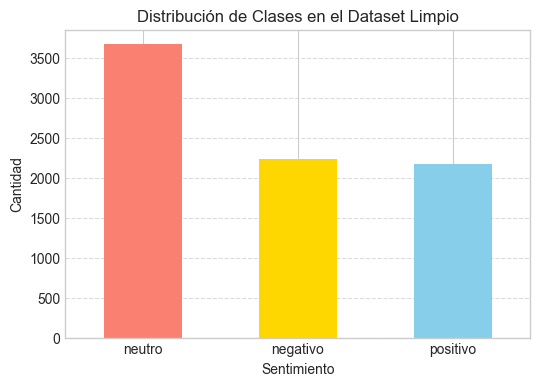

In [38]:
import matplotlib.pyplot as plt

# Graficamos la distribución de las clases del dataset limpio
plt.figure(figsize=(6, 4))
df_limpio['sentimiento'].value_counts().plot(kind='bar', color=['salmon', 'gold', 'skyblue'])
plt.xlabel('Sentimiento')
plt.ylabel('Cantidad')
plt.title('Distribución de Clases en el Dataset Limpio')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()